## Bank Customer Segmentation

### 1. Imports and data loading

In [450]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(style='darkgrid')

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [451]:
df = pd.read_csv('Credit Card Customer Data.csv')

In [452]:
df

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3
...,...,...,...,...,...,...,...
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0


In [453]:
df.shape

(660, 7)

### 2. Data Cleaning

In [454]:
dupes = df.duplicated().sum()
dupes

np.int64(0)

In [455]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [456]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0


In [457]:
df.nunique()

Sl_No                  660
Customer Key           655
Avg_Credit_Limit       110
Total_Credit_Cards      10
Total_visits_bank        6
Total_visits_online     16
Total_calls_made        11
dtype: int64

In [458]:
#There are 660 entries for 'Sl_No', but only 655 entries for 'Customer Key', indicating some potential duplicates
# Check for duplicates in the 'Customer Key' column
data_grouped = df.groupby('Customer Key').count()

for i in data_grouped.loc[data_grouped.Sl_No >= 2].index:
    display(df.loc[(df['Customer Key']) == i])

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
48,49,37252,6000,4,0,2,8
432,433,37252,59000,6,2,1,2


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
4,5,47437,100000,6,0,12,3
332,333,47437,17000,7,3,1,0


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
411,412,50706,44000,4,5,0,2
541,542,50706,60000,7,5,2,2


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
391,392,96929,13000,4,5,0,0
398,399,96929,67000,6,2,2,2


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
104,105,97935,17000,2,1,2,10
632,633,97935,187000,7,1,7,0


In [459]:
df.drop_duplicates(subset='Customer Key', keep='first', inplace=True)

In [460]:
# Drop Sl_No and Customer Key column before EDA, as it has no meaning for analysis and modeling
df.drop(columns = ['Sl_No', 'Customer Key'], inplace = True)

### 3. Exploratory Data Analysis (EDA)

In [461]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [462]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [463]:
def stacked_barplot(data, predictor, target, perc=False):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )

    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5,))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [464]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

1. Observations on Avg_Credit_Limit:

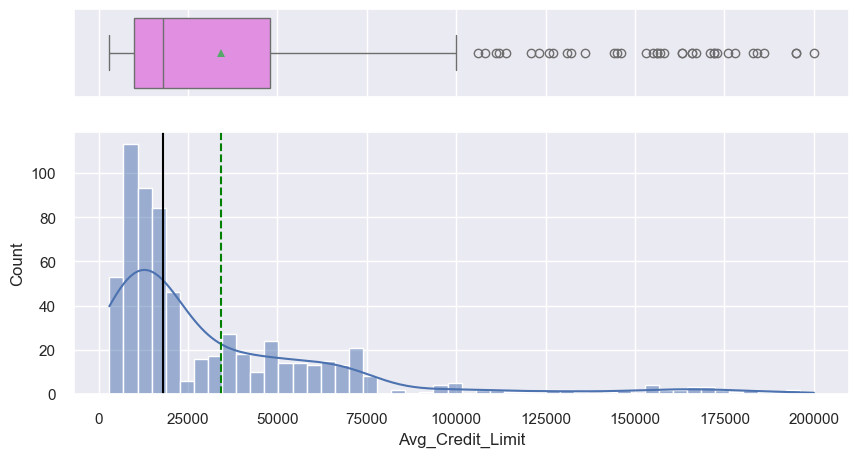

In [465]:
histogram_boxplot(df, 'Avg_Credit_Limit',bins=50, kde=True, figsize=(10, 5))

2. Observations on Total_Credit_Cards:

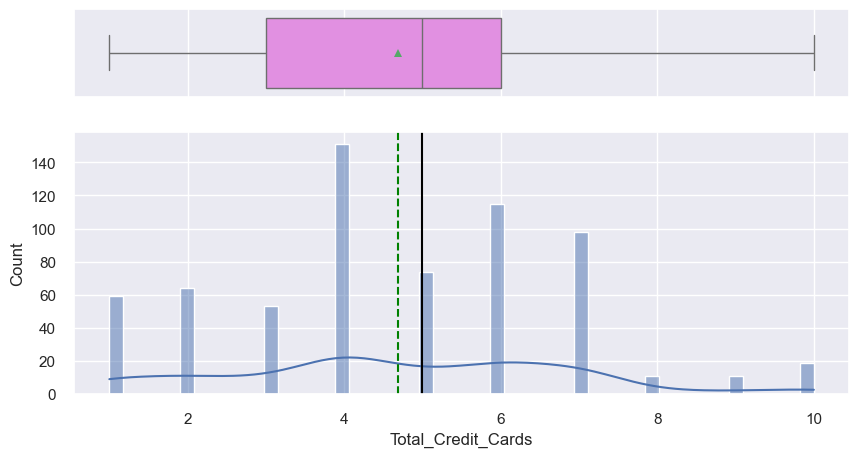

In [466]:
histogram_boxplot(df, 'Total_Credit_Cards',bins=50, kde=True, figsize=(10, 5))

3. Observations on Total_visits_bank:

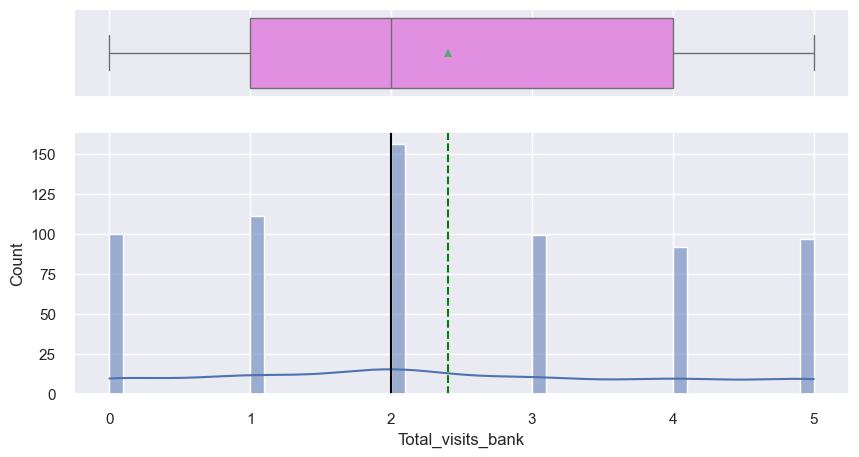

In [467]:
histogram_boxplot(df, 'Total_visits_bank',bins=50, kde=True, figsize=(10, 5))

4. Observations on Total_visits_online:

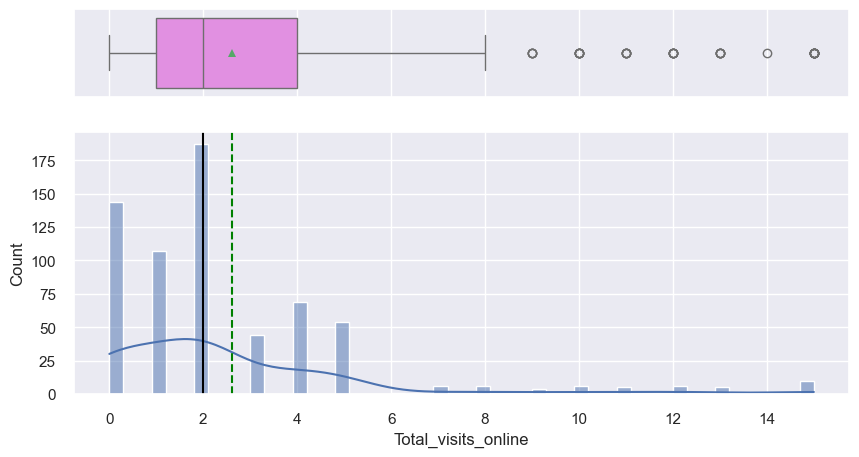

In [468]:
histogram_boxplot(df, 'Total_visits_online',bins=50, kde=True, figsize=(10, 5))

5. Observations on Total_calls_made:

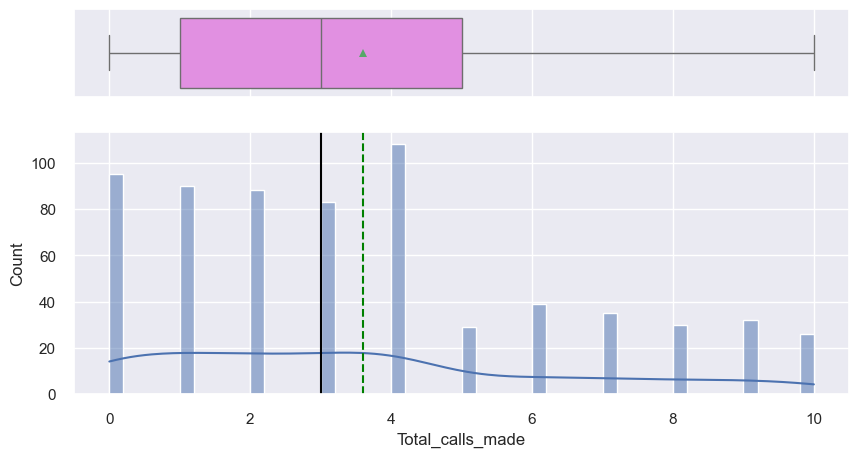

In [469]:
histogram_boxplot(df, 'Total_calls_made',bins=50, kde=True, figsize=(10, 5))

6. Correlation Analysis:

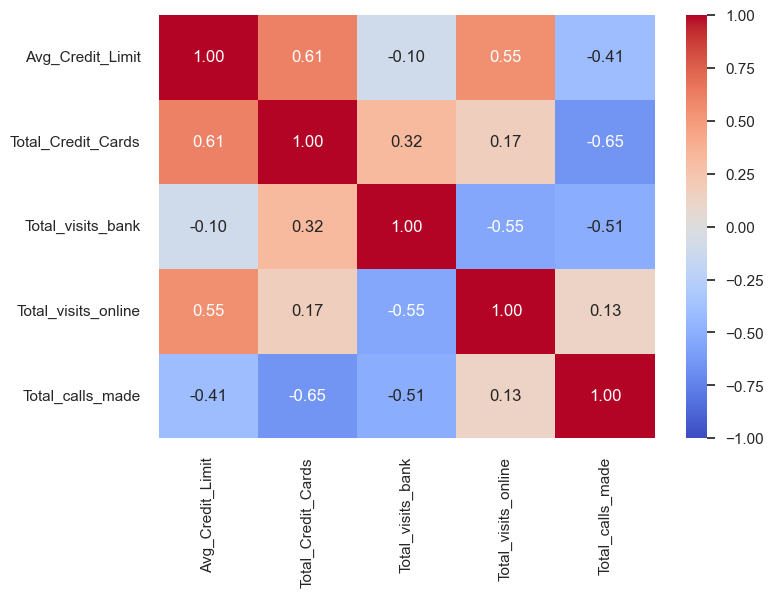

In [470]:
#list of column names including numeric data
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

# Plot heatmap
p=sns.heatmap(corr, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="coolwarm")
plt.show()

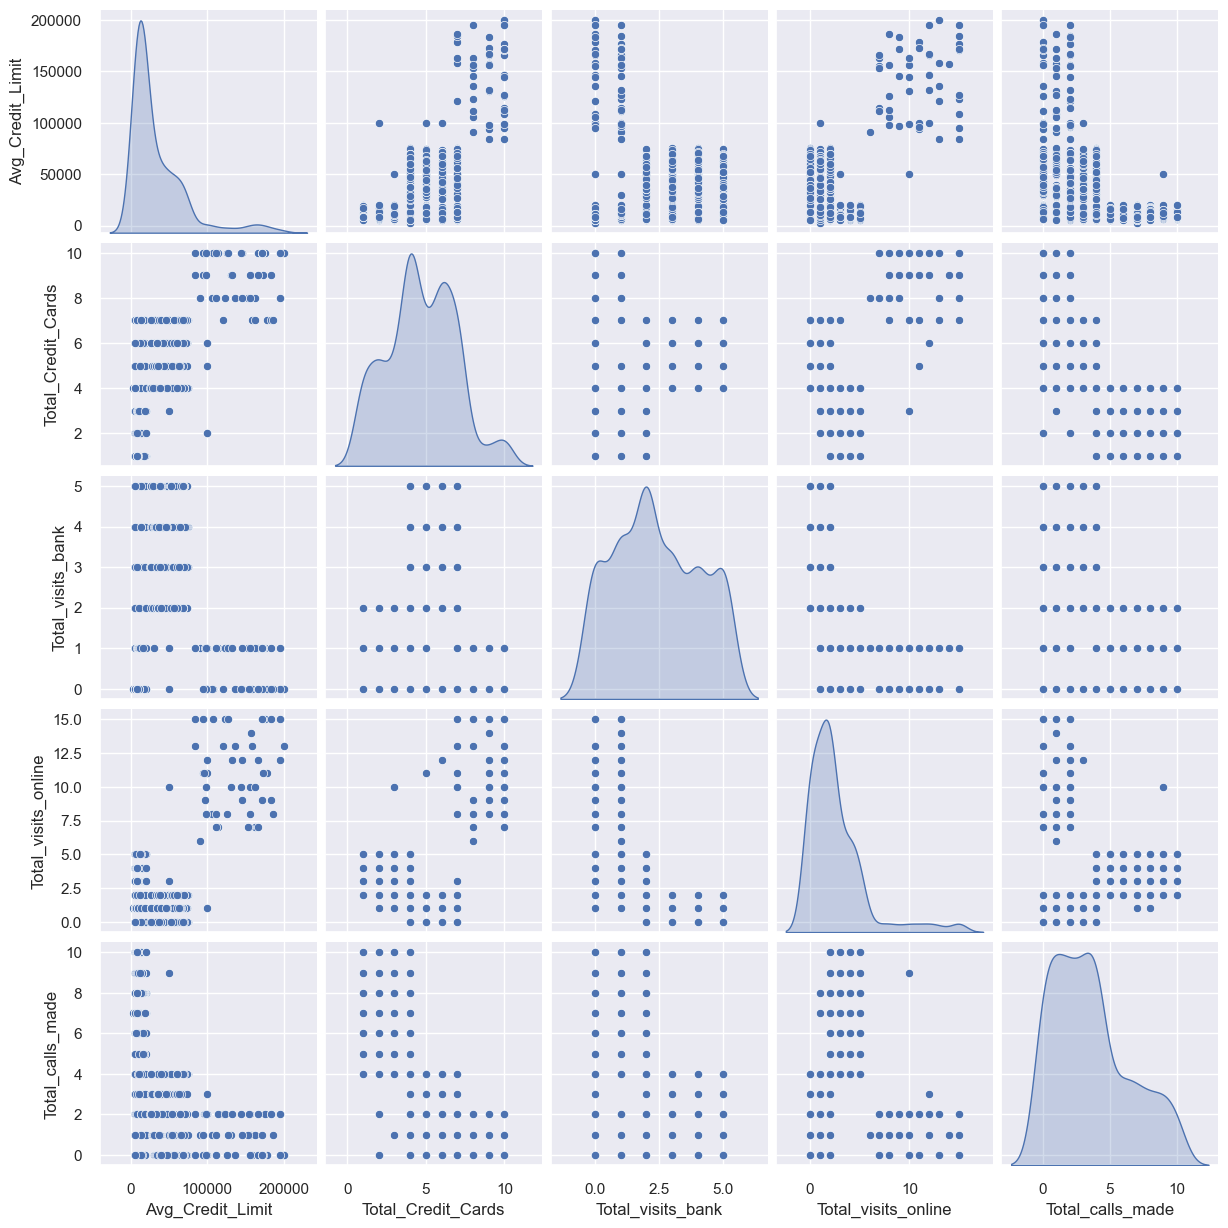

In [471]:
sns.pairplot(df, diag_kind="kde",aspect=1)
plt.show()

### 4. Outliers Detection and Removal

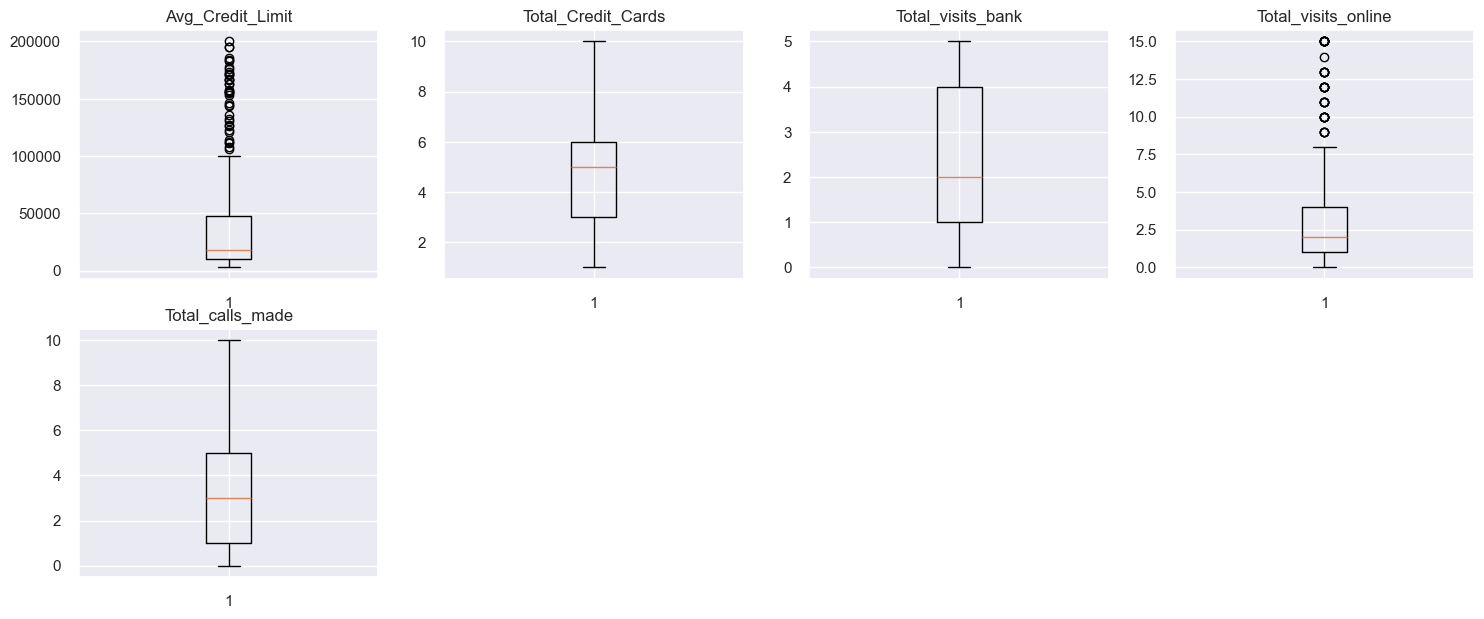

In [472]:
#Outlier detection using boxplot
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

#Formula for outlier detection
plt.figure(figsize=(15,12))

for i, variable in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    plt.boxplot(df[variable],whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [473]:
# Outlier Detection For Average Credit Limit

Q1 = df['Avg_Credit_Limit'].quantile(0.25)
Q3 = df['Avg_Credit_Limit'].quantile(0.75)

IQR = Q3 - Q1

lower_whisker = Q1 - 1.5*IQR    #Finding lower and upper bounds
upper_whisker = Q3 + 1.5*IQR

In [474]:
# Percentage of outliers in each column
((df[numerical_cols] < lower_whisker) | (df[numerical_cols] > upper_whisker)).sum()/df.shape[0]*100

Avg_Credit_Limit       5.801527
Total_Credit_Cards     0.000000
Total_visits_bank      0.000000
Total_visits_online    0.000000
Total_calls_made       0.000000
dtype: float64

In [475]:
def treat_outliers(df, col):
    """
    treats outliers in a variable
    col: str, name of the numerical variable
    df: dataframe
    col: name of the column
    """
    Q1 = df[col].quantile(0.25)  # 25th quantile
    Q3 = df[col].quantile(0.75)  # 75th quantile
    IQR = Q3 - Q1                # Inter Quantile Range (75th perentile - 25th percentile)
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR

    # all the values smaller than lower_whisker will be assigned the value of lower_whisker
    # all the values greater than upper_whisker will be assigned the value of upper_whisker
    # the assignment will be done by using the clip function of NumPy
    df[col] = np.clip(df[col], lower_whisker, upper_whisker)

    return df

In [476]:
dat = treat_outliers(df,'Avg_Credit_Limit')

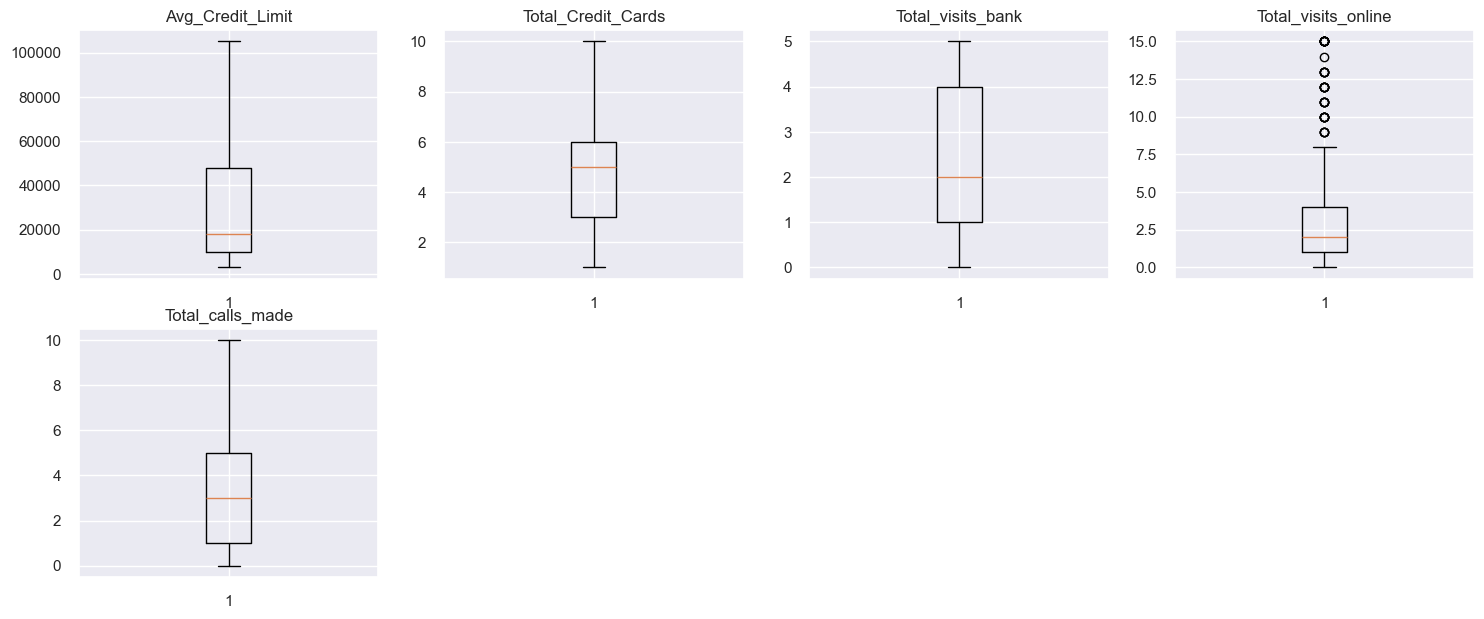

In [477]:
#boxplot after outliers treatment
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

#Formula for outlier detection
plt.figure(figsize=(15,12))

for i, variable in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    plt.boxplot(df[variable],whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [478]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 655 entries, 0 to 659
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Avg_Credit_Limit     655 non-null    int64
 1   Total_Credit_Cards   655 non-null    int64
 2   Total_visits_bank    655 non-null    int64
 3   Total_visits_online  655 non-null    int64
 4   Total_calls_made     655 non-null    int64
dtypes: int64(5)
memory usage: 30.7 KB


### 5. Data Scaling

In [479]:
#variable used for clustering
numerical_cols

['Avg_Credit_Limit',
 'Total_Credit_Cards',
 'Total_visits_bank',
 'Total_visits_online',
 'Total_calls_made']

In [480]:
from sklearn.preprocessing import StandardScaler
sclaler = StandardScaler()
subset = df[numerical_cols].copy()
subset_scaled = sclaler.fit_transform(subset)

In [481]:
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

### 6. Model Training

#### 6.1. K-Means Clustering:

In [482]:
k_means_df = subset_scaled_df.copy()

Number of Clusters: 1 	Average Distortion: 2.044353007149101
Number of Clusters: 2 	Average Distortion: 1.7550594154938237
Number of Clusters: 3 	Average Distortion: 1.181814885591652
Number of Clusters: 4 	Average Distortion: 1.0688018657968599
Number of Clusters: 5 	Average Distortion: 1.0118201435751109
Number of Clusters: 6 	Average Distortion: 0.9782828254921824
Number of Clusters: 7 	Average Distortion: 0.9087113343877757
Number of Clusters: 8 	Average Distortion: 0.8863713270778475


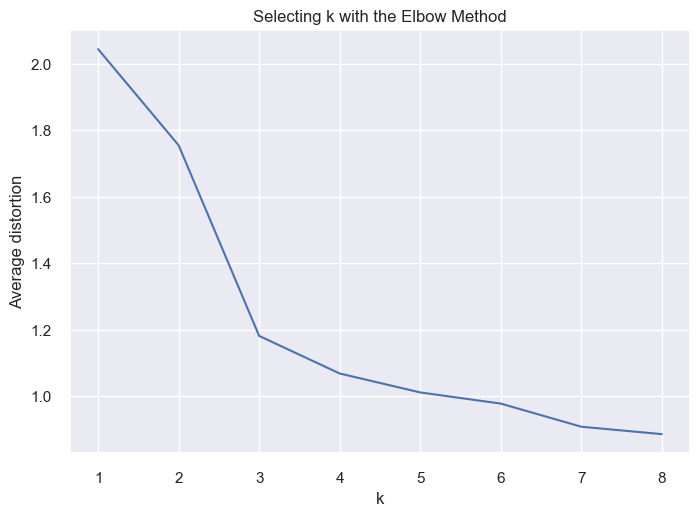

In [483]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist, pdist
clusters = range(1, 9)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    distortion = (
        sum(
            np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
        )
        /subset_scaled_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average distortion")
plt.title("Selecting k with the Elbow Method")
plt.show()

Cross Validation with Silhouette Score:

For n_clusters = 2, the silhouette score is 0.5424748172853491)
For n_clusters = 3, the silhouette score is 0.5075035671327102)
For n_clusters = 4, the silhouette score is 0.379950520643679)
For n_clusters = 5, the silhouette score is 0.28328160507653344)
For n_clusters = 6, the silhouette score is 0.2636532639532788)
For n_clusters = 7, the silhouette score is 0.2682728211651859)
For n_clusters = 8, the silhouette score is 0.23665009143526874)
For n_clusters = 9, the silhouette score is 0.25093058317389855)


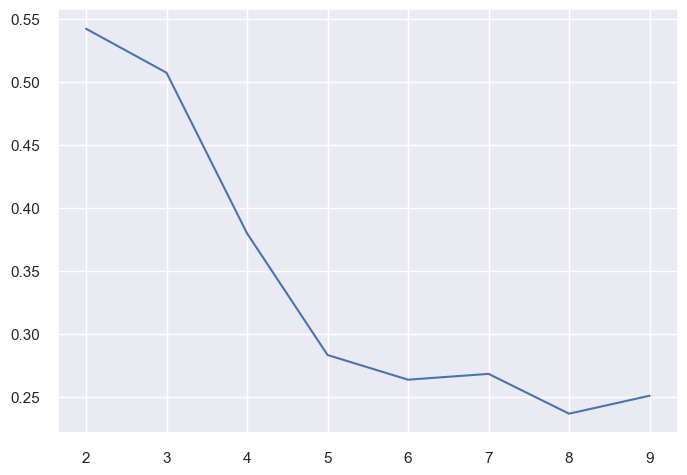

In [484]:
from sklearn.metrics import silhouette_score
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict((subset_scaled_df))
    # centers = clusterer.cluster_centers_
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

In [485]:
!pip install yellowbrick

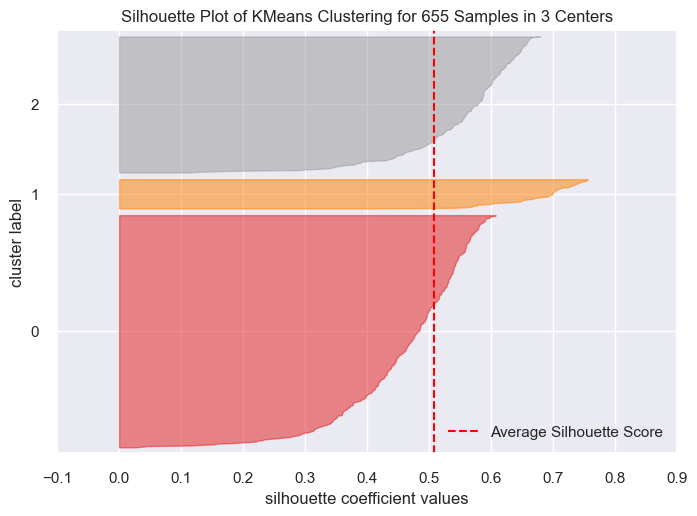

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 655 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [486]:
# finding optimal no. of clusters with silhouette coefficients
from yellowbrick.cluster import SilhouetteVisualizer
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

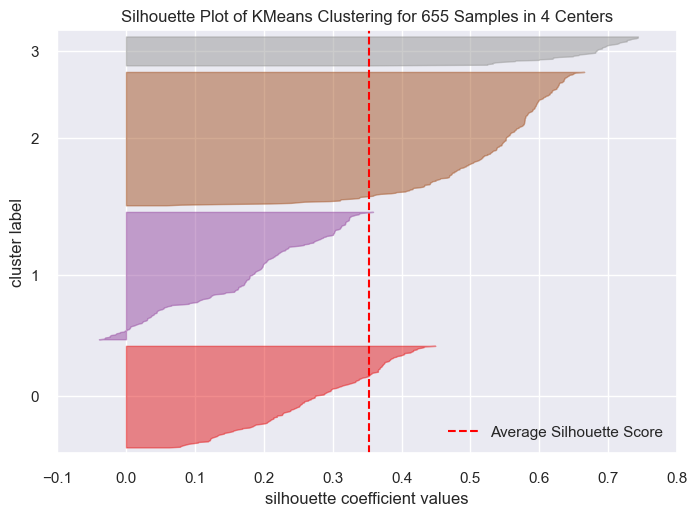

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 655 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [487]:
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

In [488]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(subset_scaled_df)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [489]:
df["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_


In [490]:
#labels of the clusters
kmeans.labels_

array([0, 2, 0, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [491]:
kmeans.cluster_centers_

array([[ 0.07637425,  0.37534925,  0.66971179, -0.55466047, -0.55713801],
       [ 2.50900334,  1.88400954, -1.1086068 ,  2.84993247, -0.87237133],
       [-0.67908985, -1.05223161, -0.89959005,  0.32247147,  1.14095052]])

In [492]:
#cluster profile
km_cluster_profile = df.groupby("K_means_segments").mean(numeric_only=True)

In [493]:
km_cluster_profile["count_in_each_segments"] = (
    df.groupby("K_means_segments")["Avg_Credit_Limit"].count().values
)

In [494]:
# Display cluster profiles
km_cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segments
K_means_segments,,,,,,
0,33604.712042,5.505236,3.494764,0.976440,2.005236,382
1,102612.244898,8.775510,0.591837,10.979592,1.102041,49
2,12174.107143,2.410714,0.933036,3.553571,6.870536,224


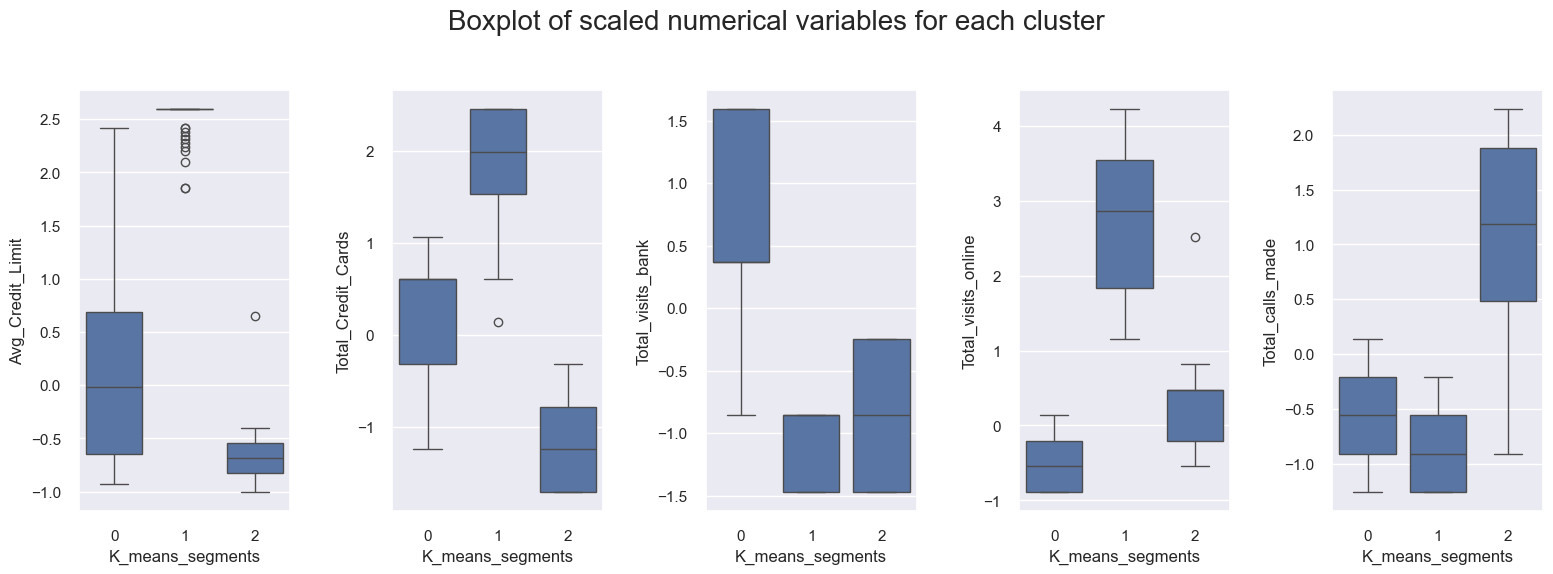

In [495]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(
        ax=axes[ii],
        y=subset_scaled_df[numerical_cols[counter]],
        x=subset_scaled_df["K_means_segments"],
    )
    counter = counter + 1

fig.tight_layout(pad=2.0)

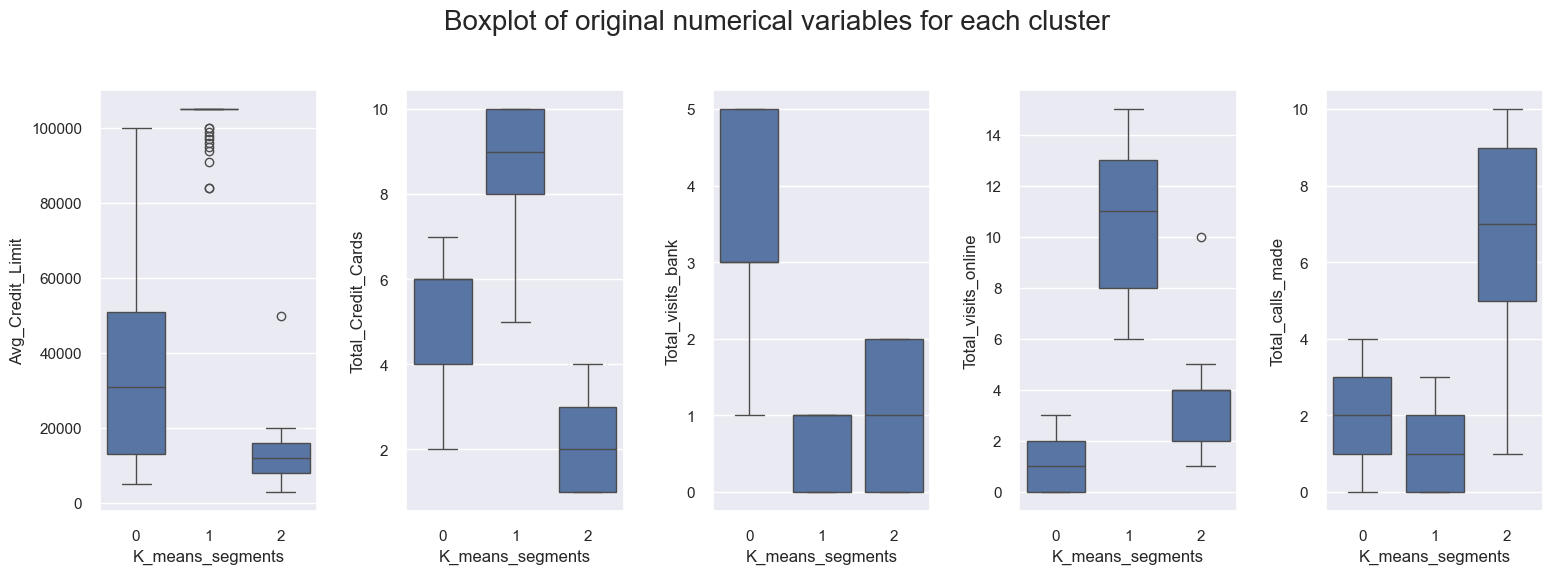

In [496]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of original numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii], y=df[numerical_cols[counter]], x=df["K_means_segments"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

Data Insights:
1. If we look at the data we see that there is a group which prefers online interactions with their bank, they have a much higher credit limit and also have more credit cards (cluster - 1), but this group has minimum no. of customers .

2. The customers who prefer in-person interactions tend to have the mid-range of credit cards and credit limit (cluster - 0) and this group has highest number of customers .

3. The customers who contact via phonecall are in another segment, who have lowest credit limit and number of cards (cluster - 2).

#### 6.2. Hierarchical Clustering:

In [497]:
hc_df = subset_scaled_df.copy()

In [498]:
# list of distance metrics
from scipy.cluster.hierarchy import cophenet, linkage
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(subset_scaled_df))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm


Cophenetic correlation for Euclidean distance and single linkage is 0.8578344969023507.
Cophenetic correlation for Euclidean distance and complete linkage is 0.9137739104180629.
Cophenetic correlation for Euclidean distance and average linkage is 0.9213186990735049.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8830684700653093.
Cophenetic correlation for Chebyshev distance and single linkage is 0.7839986635444128.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.8943048812083814.
Cophenetic correlation for Chebyshev distance and average linkage is 0.9104890883022232.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.9122285283403511.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.8480211642091331.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.5018048919345229.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.8124513247469299.
Cophenetic co

In [499]:

print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.9213186990735049, which is obtained with Euclidean distance and average linkage.


In [500]:
# list of linkage methods

linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(subset_scaled_df, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(subset_scaled_df))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.8578344969023507.
Cophenetic correlation for complete linkage is 0.9137739104180629.
Cophenetic correlation for average linkage is 0.9213186990735049.
Cophenetic correlation for centroid linkage is 0.9158880076877216.
Cophenetic correlation for ward linkage is 0.8221256065298996.
Cophenetic correlation for weighted linkage is 0.8830684700653093.


In [501]:
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.9213186990735049, which is obtained with average linkage.


Dendogram:

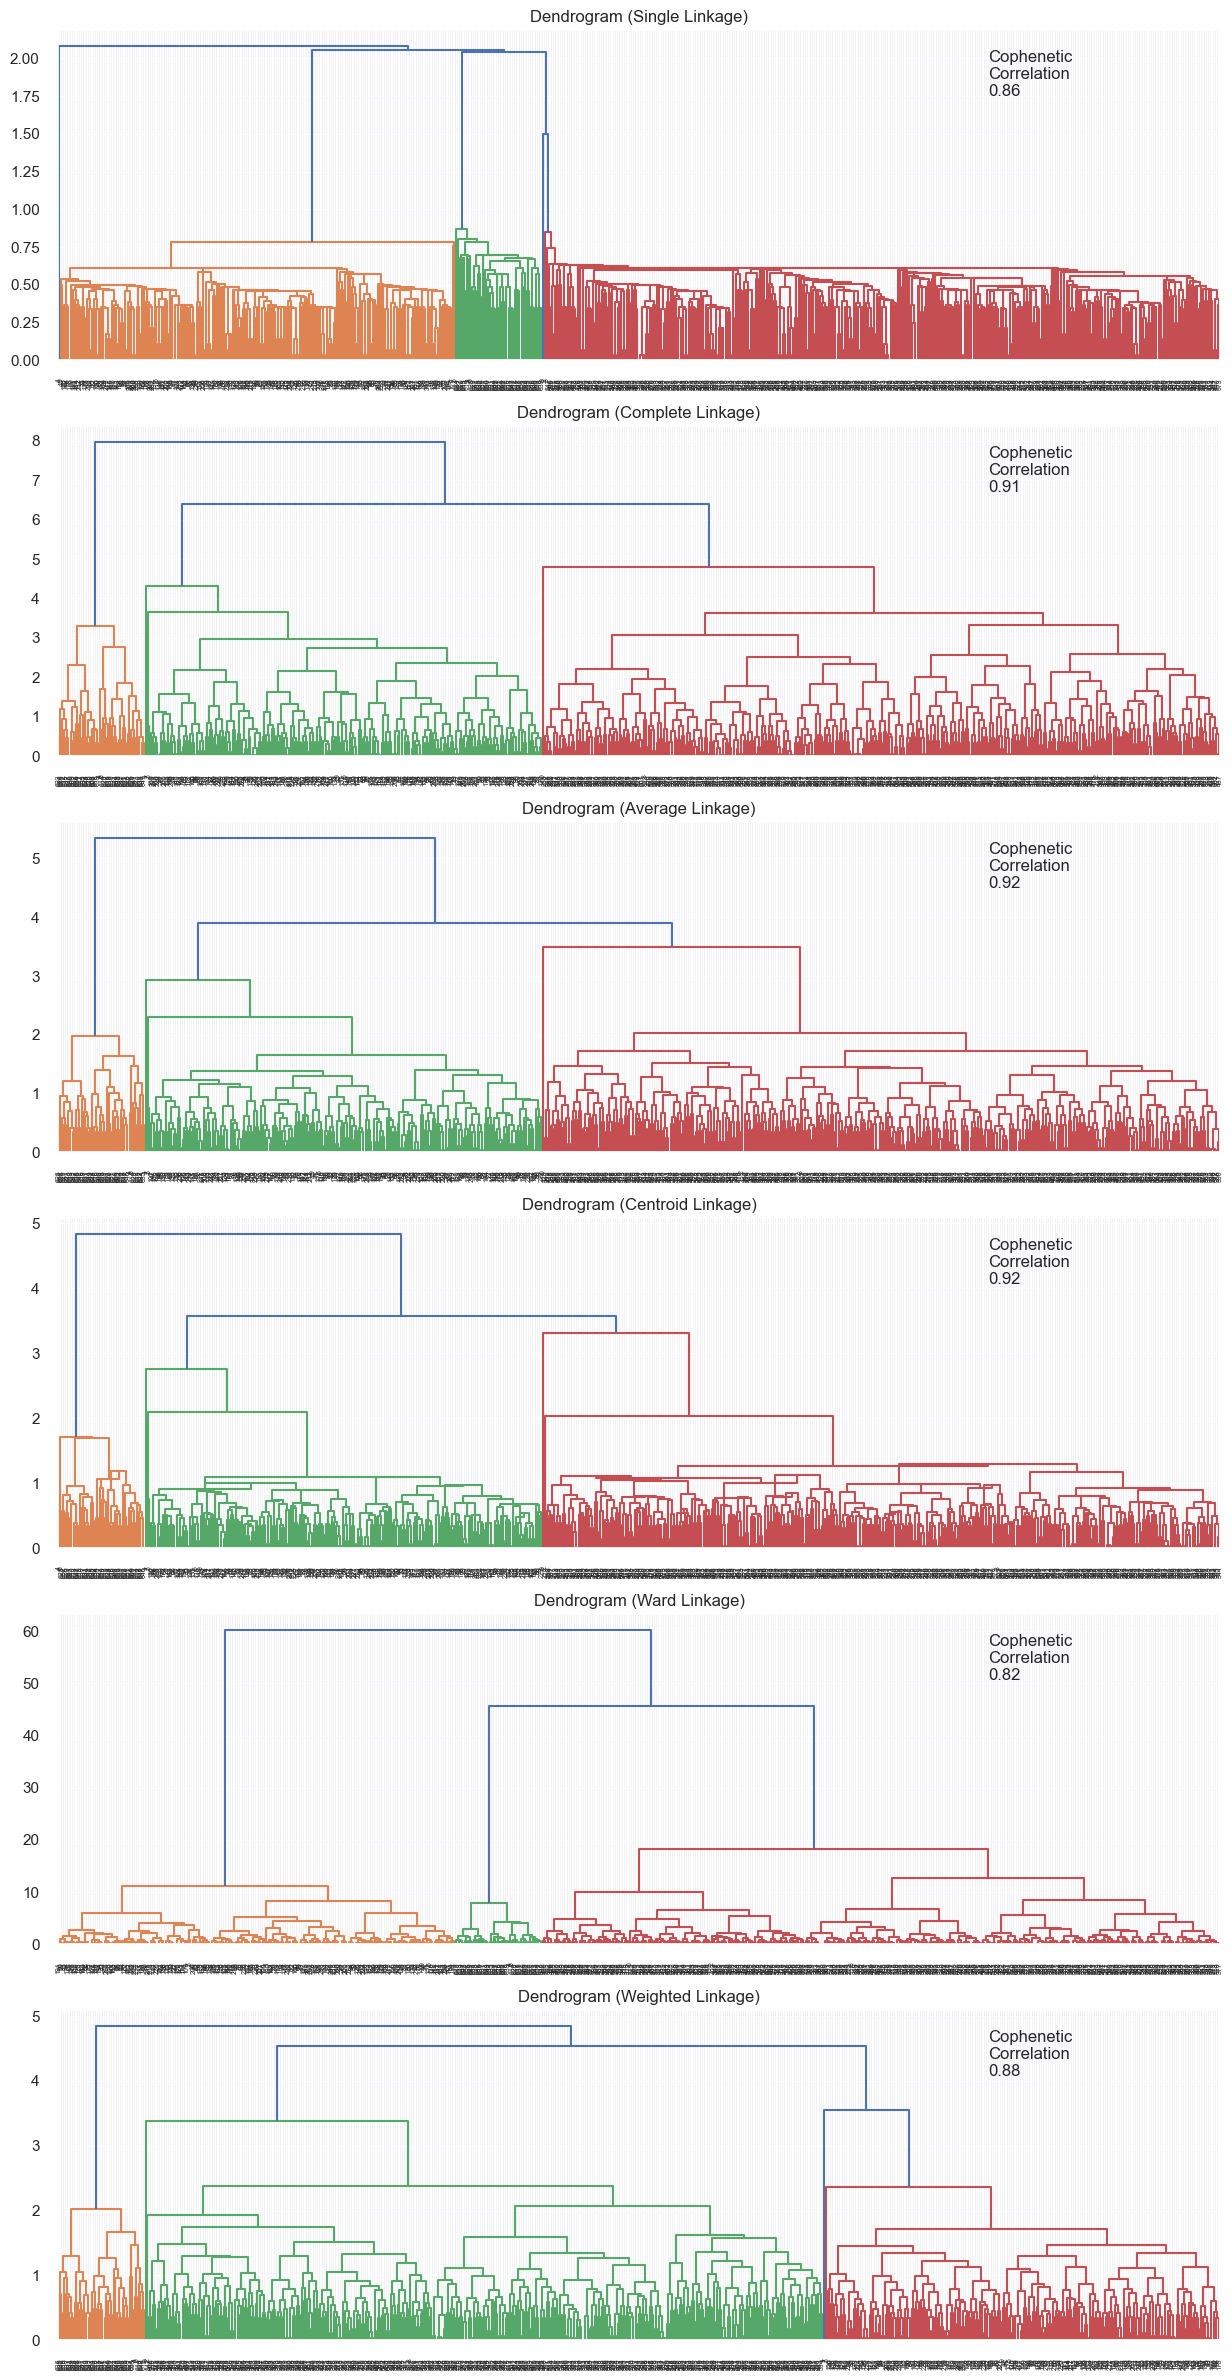

In [502]:
# list of linkage methods
from scipy.cluster.hierarchy import dendrogram
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(subset_scaled_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )
    compare.append([method, coph_corr])


In [503]:
df_cc = pd.DataFrame(compare, columns=compare_cols)
df_cc = df_cc.sort_values(by="Cophenetic Coefficient")
df_cc

,Linkage,Cophenetic Coefficient
4,ward,0.822126
0,single,0.857834
5,weighted,0.883068
1,complete,0.913774
3,centroid,0.915888
2,average,0.921319


In [504]:
from sklearn.cluster import AgglomerativeClustering
HCmodel = AgglomerativeClustering(n_clusters=4, linkage="ward")
HCmodel.fit(subset_scaled_df)

,n_clusters,4
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [505]:
subset_scaled_df["HC_Clusters"] = HCmodel.labels_
df["HC_Clusters"] = HCmodel.labels_

In [506]:
cluster_profile = df.groupby("HC_Clusters").mean(numeric_only = True)

In [507]:
cluster_profile["count_in_each_segments"] = (
    df.groupby("HC_Clusters")["Avg_Credit_Limit"].count().values
)

In [508]:
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,K_means_segments,count_in_each_segments
HC_Clusters,,,,,,,
0,19170.940171,5.559829,3.692308,1.008547,1.970085,0.000000,234
1,12174.107143,2.410714,0.933036,3.553571,6.870536,2.000000,224
2,102612.244898,8.775510,0.591837,10.979592,1.102041,1.000000,49
3,56425.675676,5.418919,3.182432,0.925676,2.060811,0.000000,148


### Model Comparison: K-Mens vs Hierarchical Clustering

In [509]:
km_cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segments
K_means_segments,,,,,,
0,33604.712042,5.505236,3.494764,0.976440,2.005236,382
1,102612.244898,8.775510,0.591837,10.979592,1.102041,49
2,12174.107143,2.410714,0.933036,3.553571,6.870536,224


In [510]:
cluster_profile.style.highlight_max(color="lightblue", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,K_means_segments,count_in_each_segments
HC_Clusters,,,,,,,
0,19170.940171,5.559829,3.692308,1.008547,1.970085,0.000000,234
1,12174.107143,2.410714,0.933036,3.553571,6.870536,2.000000,224
2,102612.244898,8.775510,0.591837,10.979592,1.102041,1.000000,49
3,56425.675676,5.418919,3.182432,0.925676,2.060811,0.000000,148


<Axes: xlabel='K_means_segments'>

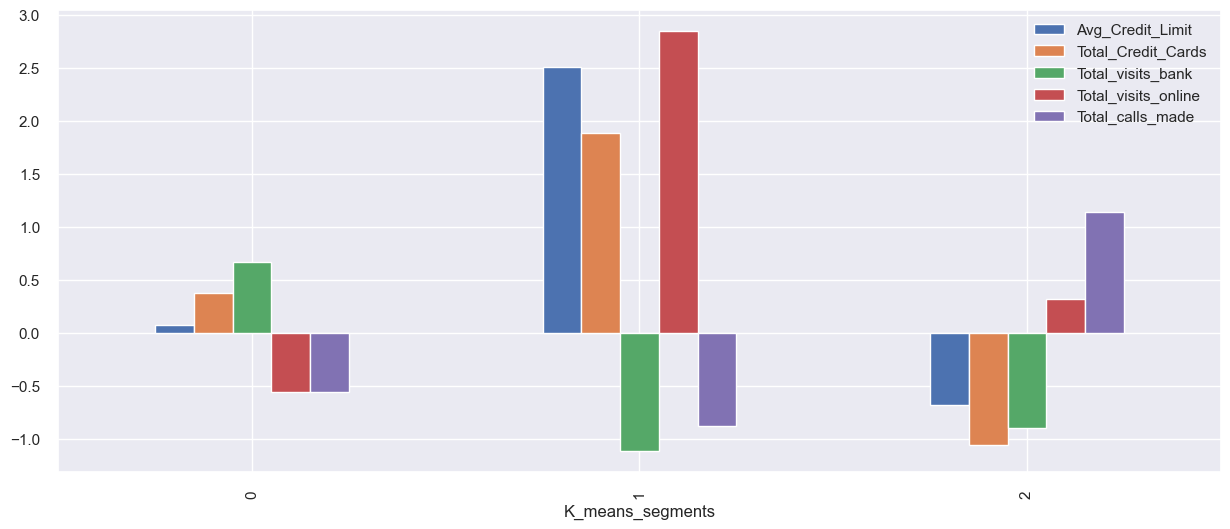

In [511]:
df["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_
k_means_df["K_means_segments"] = kmeans.labels_
k_means_df.groupby("K_means_segments").mean().plot.bar(figsize=(15, 6))

<Axes: xlabel='HC_Clusters'>

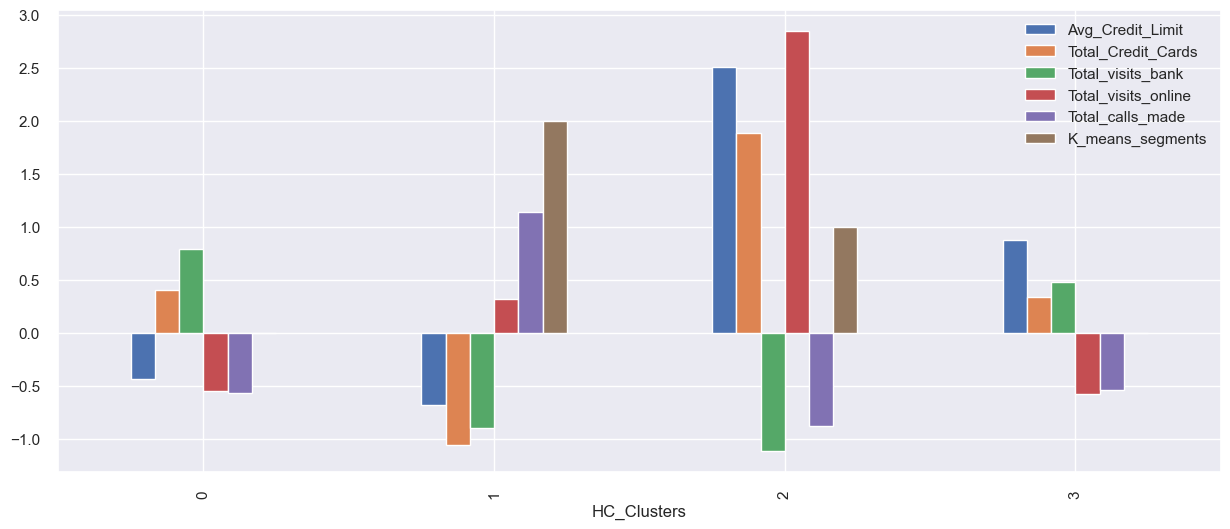

In [512]:
subset_scaled_df["HC_Clusters"] = HCmodel.labels_
df["HC_Clusters"] = HCmodel.labels_
subset_scaled_df.groupby("HC_Clusters").mean().plot.bar(figsize=(15, 6))